<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:2: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_741/518316080.py:2: SyntaxWarning: invalid escape sequence '\ '
  sys.path.append('/Users/sim/Desktop/MECH\ 309/Project/')


Fetching weather data...

Running main model (full feature set)...

   h | Season                 |   RMSE |    MAE | Baseline |  Improv.
---------------------------------------------------------------------------
   1h | Winter (January)       |  0.641 |  0.450 |    0.744 |    13.9%
   1h | Summer (July)          |  0.700 |  0.425 |    0.960 |    27.1%
   3h | Winter (January)       |  1.604 |  1.225 |    1.790 |    10.4%
   3h | Summer (July)          |  1.320 |  0.955 |    2.367 |    44.2%
   6h | Winter (January)       |  2.629 |  2.038 |    2.990 |    12.1%
   6h | Summer (July)          |  1.814 |  1.360 |    4.089 |    55.6%
  12h | Winter (January)       |  3.615 |  2.893 |    4.556 |    20.7%
  12h | Summer (July)          |  2.286 |  1.759 |    5.700 |    59.9%
  24h | Winter (January)       |  4.614 |  3.723 |    5.971 |    22.7%
  24h | Summer (July)          |  2.506 |  1.974 |    3.217 |    22.1%
  48h | Winter (January)       |  5.471 |  4.421 |    6.964 |    21.4%
  48h

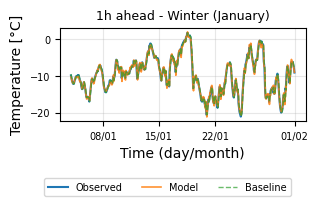

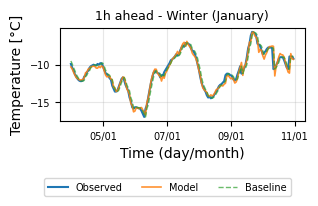

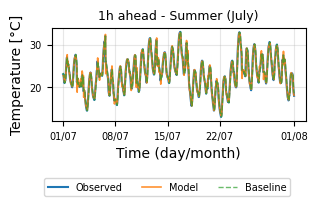

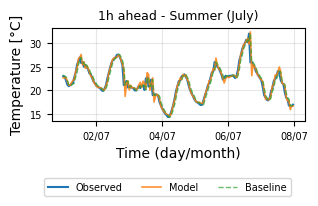

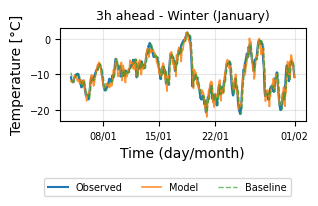

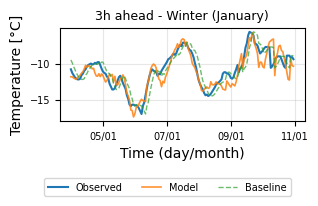

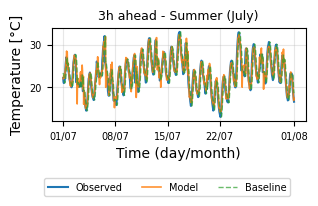

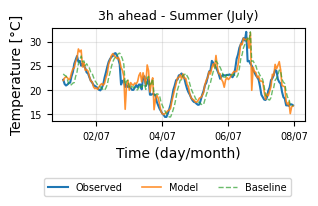

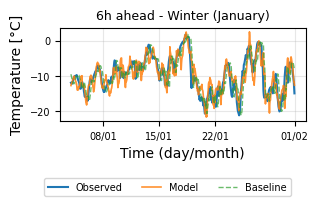

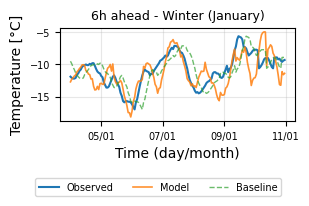

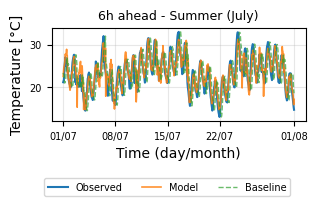

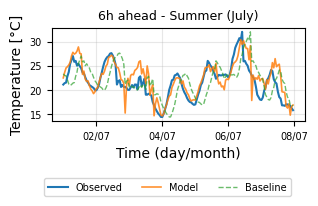

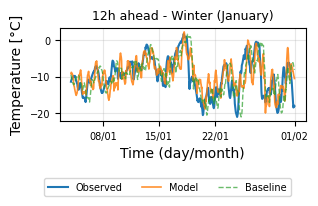

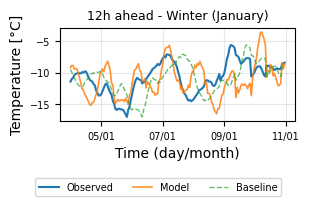

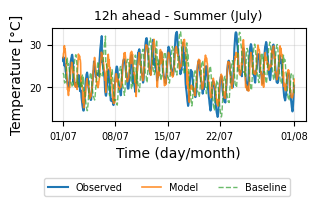

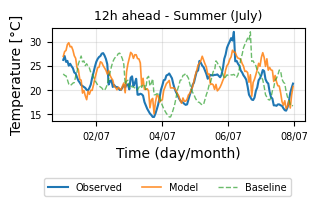

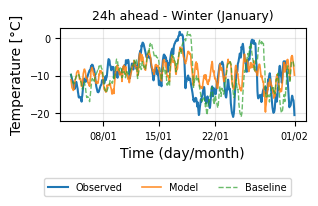

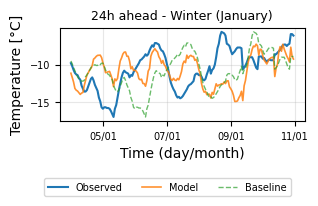

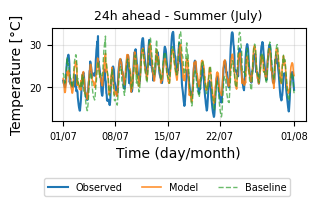

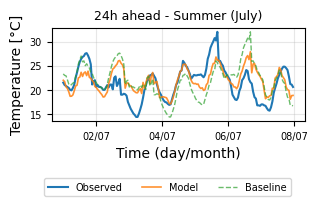

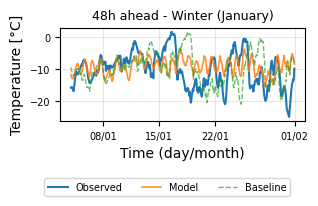

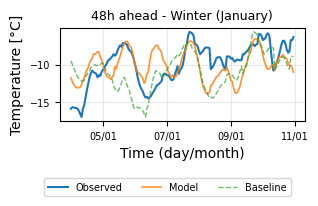

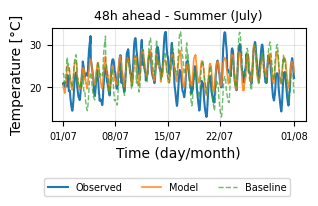

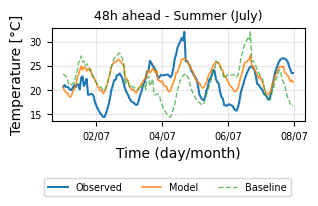

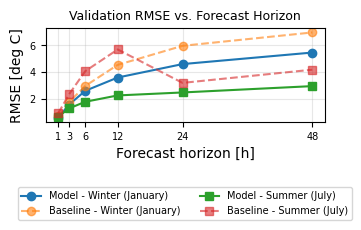

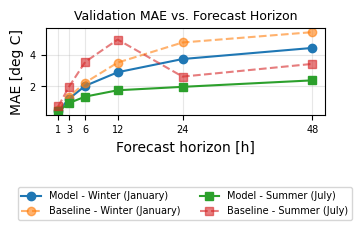

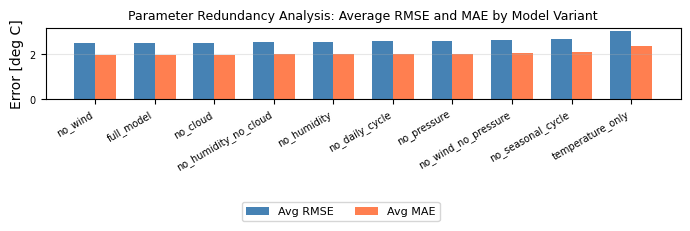

In [ ]:
#import sys
#sys.path.append('/Users/Mech309/Project/')
# ================================
# MECH 309 - Part 1
# Multi-horizon temperature prediction + feature redundancy analysis
# Horizons: 1h, 3h, 6h, 12h, 24h, 48h
# Seasonal validation: winter (January) + summer (July)
#
# Modeling strategy:
# - ridge regression fit by least squares
# - predict future temperature from current conditions,
#   lagged variables, and periodic time features
# - features are standardized before fitting for numerical stability
# - evaluate separately in winter and summer to test
#   generalization across different weather regimes
# - parameter redundancy analysis: systematically remove feature groups
#   to assess their individual contribution to prediction accuracy
#
# Figure export:
# - all figures use export.py (set_latex_style + export_figure)
# - single-column figures: 3.45 in wide, golden-ratio height
# - double-column figures: 7.10 in wide, half golden-ratio height
# - set SAVE_FIGS = True in MAIN to export PDF figures for the report
# ================================

from __future__ import annotations
import math
from dataclasses import dataclass
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt


# ================================
# Location
# ================================

@dataclass(frozen=True)
class Location:
    name: str
    lat: float
    lon: float
    timezone: str


MONTREAL = Location(
    name="Montreal, QC",
    lat=45.5017,
    lon=-73.5673,
    timezone="America/Montreal",
)


# ================================
# Data acquisition
# ================================

def fetch_open_meteo_hourly(
    start_date: str,
    end_date: str,
    location: Location = MONTREAL,
) -> pd.DataFrame:
    """
    Download hourly weather data from Open-Meteo archive API.

    Variables:
    - T     : 2m air temperature [deg C]
    - W     : 10m wind speed [km/h]
    - RH    : relative humidity [%]
    - P     : surface pressure [hPa]
    - Cloud : cloud cover [%]
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":   location.lat,
        "longitude":  location.lon,
        "start_date": start_date,
        "end_date":   end_date,
        "hourly": ",".join([
            "temperature_2m",
            "wind_speed_10m",
            "relative_humidity_2m",
            "surface_pressure",
            "cloud_cover",
        ]),
        "timezone": location.timezone,
    }

    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    payload = r.json()

    hourly = payload["hourly"]
    idx = pd.to_datetime(hourly["time"])

    df = pd.DataFrame(index=idx)
    df["T"]     = hourly["temperature_2m"]
    df["W"]     = hourly["wind_speed_10m"]
    df["RH"]    = hourly["relative_humidity_2m"]
    df["P"]     = hourly["surface_pressure"]
    df["Cloud"] = hourly["cloud_cover"]
    df.index.name = "time_local"
    return df


# ================================
# Preprocessing
# ================================

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean the raw weather DataFrame and add periodic time features.

    Steps:
    1. Sort and de-duplicate the time index.
    2. Reindex to a complete hourly grid so every lag is valid.
    3. Fill short gaps by interpolation, then forward/back-fill endpoints.
    4. Encode time-of-day and day-of-year as sine/cosine pairs so the
       representation is cyclic (no discontinuity at day or year boundary).
    """
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="first")]

    full_idx = pd.date_range(
        df.index.min(), df.index.max(), freq="h", tz=df.index.tz
    )
    df = df.reindex(full_idx)
    df = df.interpolate(limit=6).ffill().bfill()

    hour = df.index.hour.to_numpy()
    doy  = df.index.dayofyear.to_numpy()

    df["sin_day"]  = np.sin(2 * math.pi / 24     * hour)
    df["cos_day"]  = np.cos(2 * math.pi / 24     * hour)
    df["sin_year"] = np.sin(2 * math.pi / 365.25 * doy)
    df["cos_year"] = np.cos(2 * math.pi / 365.25 * doy)

    return df


# ================================
# Lagged predictors
# ================================

def add_lags(df: pd.DataFrame, col: str, lags: list[int]) -> pd.DataFrame:
    """Add lagged copies of `col` as new columns."""
    for L in lags:
        df[f"{col}_lag{L}"] = df[col].shift(L)
    return df


# ================================
# Error metrics
# ================================

def rmse(y: np.ndarray, yhat: np.ndarray) -> float:
    """Root-mean-square error -- penalises large deviations strongly."""
    return float(np.sqrt(np.mean((y - yhat) ** 2)))


def mae(y: np.ndarray, yhat: np.ndarray) -> float:
    """Mean absolute error -- directly interpretable in deg C."""
    return float(np.mean(np.abs(y - yhat)))


# ================================
# Feature scaling
# ================================

def fit_scaler(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute column-wise mean and std on training data.

    Standardizing is critical because predictors span very different
    numerical ranges (pressure ~1000 hPa vs cloud cover 0-100).
    Without scaling the normal equations become ill-conditioned and
    ridge regularization is inconsistent across features.
    """
    mu  = X.mean(axis=0)
    sig = X.std(axis=0)
    sig[sig == 0] = 1.0   # avoid division by zero for constant columns
    return mu, sig


def apply_scaler(X: np.ndarray, mu: np.ndarray, sig: np.ndarray) -> np.ndarray:
    """Apply pre-computed standardization to a feature matrix."""
    return (X - mu) / sig


# ================================
# Seasonal split
# ================================

def seasonal_split(
    df: pd.DataFrame, year: int, month: int
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Hold out one calendar month as the validation set.
    All remaining months form the training set.
    """
    val_mask = (df.index.year == year) & (df.index.month == month)
    return df.loc[~val_mask].copy(), df.loc[val_mask].copy()


# ================================
# Ridge regression
# ================================

def fit_ridge(
    X_train: np.ndarray,
    y_train: np.ndarray,
    alpha: float = 0.1,
) -> np.ndarray:
    """
    Fit ridge regression: minimise ||X theta - y||^2 + alpha * ||theta||^2.

    Closed-form solution via the regularised normal equations:
        theta = (X^T X + alpha * I)^{-1} X^T y

    np.linalg.solve is used instead of explicit inversion for
    numerical stability.

    Parameters
    ----------
    alpha : regularization strength (0 recovers ordinary least squares)
    """
    n = X_train.shape[1]
    A = X_train.T @ X_train + alpha * np.eye(n)
    b = X_train.T @ y_train
    return np.linalg.solve(A, b)


# ================================
# Core model runner
# ================================

def run_model(
    df_base: pd.DataFrame,
    feature_cols: list[str],
    h: int,
    year: int,
    month: int,
    month_name: str = "",
    alpha: float = 0.1,
) -> dict:
    """
    Train and evaluate one ridge regression model for a given
    feature set, forecast horizon, and validation month.

    The target at time k is T(k+h), constructed by shifting the
    temperature column backward by h steps so each row uses only
    past information to predict future temperature.

    Returns a dict with metrics, predictions, and named coefficients.
    """
    df = df_base.copy()
    df["T_target"] = df["T"].shift(-h)
    df = df.dropna().copy()

    train_df, val_df = seasonal_split(df, year, month)

    X_train_raw = train_df[feature_cols].to_numpy()
    y_train     = train_df["T_target"].to_numpy()
    X_val_raw   = val_df[feature_cols].to_numpy()
    y_val       = val_df["T_target"].to_numpy()

    # Standardize using training statistics only (no leakage)
    mu, sig     = fit_scaler(X_train_raw)
    X_train     = apply_scaler(X_train_raw, mu, sig)
    X_val       = apply_scaler(X_val_raw,   mu, sig)

    # Intercept added after scaling
    X_train = np.column_stack([np.ones(len(X_train)), X_train])
    X_val   = np.column_stack([np.ones(len(X_val)),   X_val])

    theta      = fit_ridge(X_train, y_train, alpha=alpha)
    yhat_train = X_train @ theta
    yhat_val   = X_val   @ theta
    baseline   = val_df["T"].to_numpy()

    coef_names   = ["intercept"] + feature_cols
    coefficients = dict(zip(coef_names, theta))

    return {
        "h":             h,
        "month_name":    month_name,
        "n_features":    len(feature_cols),
        "train_rmse":    rmse(y_train,  yhat_train),
        "val_rmse":      rmse(y_val,    yhat_val),
        "val_mae":       mae(y_val,     yhat_val),
        "baseline_rmse": rmse(y_val,    baseline),
        "val_index":     val_df.index,
        "y_val":         y_val,
        "yhat":          yhat_val,
        "baseline":      baseline,
        "coefficients":  coefficients,
    }


# ================================
# Reporting helpers
# ================================

def print_results(results: list[dict]) -> None:
    """Print a formatted main results table to stdout."""
    print("\n" + "=" * 75)
    print(f"{'h':>4} | {'Season':<22} | {'RMSE':>6} | {'MAE':>6} | "
          f"{'Baseline':>8} | {'Improv.':>8}")
    print("-" * 75)
    for r in results:
        imp = 100 * (r["baseline_rmse"] - r["val_rmse"]) / r["baseline_rmse"]
        print(
            f"{r['h']:>4}h | {r['month_name']:<22} | "
            f"{r['val_rmse']:>6.3f} | {r['val_mae']:>6.3f} | "
            f"{r['baseline_rmse']:>8.3f} | {imp:>7.1f}%"
        )
    print("=" * 75)


def save_results_table(
    results: list[dict], path: str = "results_table.csv"
) -> pd.DataFrame:
    """Save RMSE/MAE summary to CSV for the report."""
    rows = []
    for r in results:
        imp = 100 * (r["baseline_rmse"] - r["val_rmse"]) / r["baseline_rmse"]
        rows.append({
            "Horizon (h)":        r["h"],
            "Season":             r["month_name"],
            "Train RMSE (deg C)": round(r["train_rmse"],    3),
            "Val RMSE (deg C)":   round(r["val_rmse"],      3),
            "Val MAE (deg C)":    round(r["val_mae"],       3),
            "Baseline RMSE (deg C)": round(r["baseline_rmse"], 3),
            "Improvement (%)":    round(imp,                1),
        })
    table = pd.DataFrame(rows)
    table.to_csv(path, index=False)
    print(f"\nResults table saved to: {path}")
    return table


def print_coefficients(result: dict, top_n: int = 10) -> None:
    """Print the top-N coefficients by absolute magnitude."""
    coefs = result["coefficients"]
    sorted_coefs = sorted(coefs.items(), key=lambda x: abs(x[1]), reverse=True)
    print(f"\nTop {top_n} coefficients  h={result['h']}h -- {result['month_name']}:")
    for name, val in sorted_coefs[:top_n]:
        print(f"  {name:<20s}: {val:+.4f}")


# ================================
# Parameter redundancy analysis helpers
# ================================

def run_redundancy_analysis(
    df: pd.DataFrame,
    feature_groups: dict[str, list[str]],
    full_features: list[str],
    horizons: list[int],
    validation_months: list[tuple],
    alpha: float = 0.1,
) -> pd.DataFrame:
    """
    Run a systematic parameter redundancy analysis.

    For each variant (full model + one-group-removed models), trains
    and evaluates the model for every horizon/season combination.
    Returns a DataFrame with one row per (model, horizon, season).
    """
    feature_sets = {
        "full_model":          full_features,
        "temperature_only":    feature_groups["temperature_core"],
        "no_wind":             [f for f in full_features if f not in feature_groups["wind"]],
        "no_humidity":         [f for f in full_features if f not in feature_groups["humidity"]],
        "no_pressure":         [f for f in full_features if f not in feature_groups["pressure"]],
        "no_cloud":            [f for f in full_features if f not in feature_groups["cloud"]],
        "no_daily_cycle":      [f for f in full_features if f not in feature_groups["daily_cycle"]],
        "no_seasonal_cycle":   [f for f in full_features if f not in feature_groups["seasonal_cycle"]],
        "no_wind_no_pressure": [f for f in full_features
                                if f not in feature_groups["wind"] + feature_groups["pressure"]],
        "no_humidity_no_cloud":[f for f in full_features
                                if f not in feature_groups["humidity"] + feature_groups["cloud"]],
    }

    rows = []
    for model_name, feats in feature_sets.items():
        print(f"  Running redundancy variant: {model_name} ({len(feats)} features)...")
        for h in horizons:
            for year, month, season_name in validation_months:
                res = run_model(df, feats, h, year, month, season_name, alpha=alpha)
                imp = 100 * (res["baseline_rmse"] - res["val_rmse"]) / res["baseline_rmse"]
                rows.append({
                    "model":           model_name,
                    "horizon_h":       h,
                    "season":          season_name,
                    "n_features":      len(feats),
                    "train_rmse":      round(res["train_rmse"],    3),
                    "val_rmse":        round(res["val_rmse"],      3),
                    "val_mae":         round(res["val_mae"],       3),
                    "baseline_rmse":   round(res["baseline_rmse"], 3),
                    "improvement_pct": round(imp,                  1),
                })
    return pd.DataFrame(rows)


def print_redundancy_summary(redundancy_df: pd.DataFrame) -> None:
    """Print the average-performance summary across all horizons/seasons."""
    summary = (
        redundancy_df
        .groupby("model", as_index=False)
        .agg(
            avg_rmse=("val_rmse",        "mean"),
            avg_mae= ("val_mae",         "mean"),
            avg_imp= ("improvement_pct", "mean"),
            n_feat=  ("n_features",      "first"),
        )
        .sort_values("avg_rmse")
    )

    print("\n" + "=" * 72)
    print(f"{'Model':<25} | {'Features':>8} | {'Avg RMSE':>8} | "
          f"{'Avg MAE':>7} | {'Avg Improv.':>10}")
    print("-" * 72)
    for _, row in summary.iterrows():
        print(
            f"{row['model']:<25} | {int(row['n_feat']):>8} | "
            f"{row['avg_rmse']:>8.3f} | {row['avg_mae']:>7.3f} | "
            f"{row['avg_imp']:>9.1f}%"
        )
    print("=" * 72)

    print("\n===== BEST MODEL BY HORIZON / SEASON =====")
    for h in sorted(redundancy_df["horizon_h"].unique()):
        for season in redundancy_df["season"].unique():
            subset = redundancy_df[
                (redundancy_df["horizon_h"] == h) &
                (redundancy_df["season"]    == season)
            ].sort_values("val_rmse")
            best = subset.iloc[0]
            print(
                f"h={h:>2}h | {season:<22} | best={best['model']:<25} | "
                f"RMSE={best['val_rmse']:.3f} | "
                f"Improv.={best['improvement_pct']:.1f}%"
            )


# ================================
# Plotting
# ================================

# Figure sizing constants matching the report template guidelines:
#   single column = 3.45 in, double column = 7.1 in
#   golden ratio height = width * (sqrt(5)-1)/2 ~ width * 0.618
GOLDEN_RATIO = (5 ** 0.5 - 1) / 2
SINGLE_WIDTH = 3.45
DOUBLE_WIDTH = 7.10
TICK_FONTSIZE = 7   # slightly smaller than axis labels


def plot_predictions(results: list[dict], save: bool = False) -> None:
    """
    Plot observed temperature, model prediction, and persistence baseline.

    Generates two versions for each horizon/season combination:
    - Full month  (all 744 hours) -- for reference
    - First 2 weeks (336 hours)  -- reduced density, used in the report

    When save=True figures are exported as report-ready PDFs using
    export.py (single-column width 3.45 in, golden-ratio height, LaTeX
    fonts). When save=False they are displayed interactively.
    Requires export.py to be in the same directory when save=True.
    """
    import matplotlib.dates as mdates

    if save:
        from export import set_latex_style, export_figure
        set_latex_style(fontsize=11)

    for r in results:
        for label, mask in [("full", slice(None)), ("1week", slice(0, 168))]:
            idx      = r["val_index"][mask]
            y_val    = r["y_val"][mask]
            yhat     = r["yhat"][mask]
            baseline = r["baseline"][mask]

            fig, ax = plt.subplots(
                figsize=(SINGLE_WIDTH, SINGLE_WIDTH * GOLDEN_RATIO)
            )
            l1, = ax.plot(idx, y_val,    label="Observed",     lw=1.5)
            l2, = ax.plot(idx, yhat,     label="Model",        lw=1.2, alpha=0.85)
            l3, = ax.plot(idx, baseline, "--", label="Baseline", lw=1.0, alpha=0.7)

            # X-axis: show day/month only, fewer ticks for full month
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
            if label == "full":
                ax.xaxis.set_major_locator(mdates.DayLocator(bymonthday=[1, 8, 15, 22]))
            else:
                ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
            fig.autofmt_xdate(rotation=0, ha="center")

            ax.set_title(
                f"{r['h']}h ahead - {r['month_name']}",
                fontsize=9
            )
            ax.set_xlabel("Time (day/month)")
            ax.set_ylabel("Temperature [°C]")
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)

            fig.legend(
                handles=[l1, l2, l3],
                loc="upper center",
                bbox_to_anchor=(0.55, 0.16),
                ncol=3,
                frameon=True,
                fontsize=7,
            )
            fig.tight_layout(rect=[0.05, 0.15, 1, 1])

            if save:
                season = r["month_name"].split()[0].lower()
                fname  = f"pred_h{r['h']}_{season}_{label}.pdf"
                from export import set_latex_style
                set_latex_style(fontsize=11)
                fig.set_size_inches(SINGLE_WIDTH, SINGLE_WIDTH * GOLDEN_RATIO)
                fig.savefig(fname, dpi=300, bbox_inches="tight", pad_inches=0.15)
                print(f"Saved figure: {fname}")
                plt.close(fig)
            else:
                plt.show()


def plot_rmse_vs_horizon(results: list[dict], save: bool = False) -> None:
    """
    Plot validation RMSE and baseline RMSE vs forecast horizon,
    separately for each season.

    Sized to single-column width (3.45 in) with golden-ratio height.
    Requires export.py to be in the same directory when save=True.
    """
    if save:
        from export import set_latex_style, export_figure
        set_latex_style(fontsize=11)

    seasons  = list(dict.fromkeys(r["month_name"] for r in results))
    horizons = sorted(set(r["h"] for r in results))
    markers  = ["o", "s"]

    fig, ax = plt.subplots(
        figsize=(SINGLE_WIDTH, SINGLE_WIDTH * GOLDEN_RATIO)
    )
    lines = []
    for i, season in enumerate(seasons):
        sub = sorted([r for r in results if r["month_name"] == season],
                     key=lambda r: r["h"])
        hs    = [r["h"]             for r in sub]
        rval  = [r["val_rmse"]      for r in sub]
        rbase = [r["baseline_rmse"] for r in sub]
        l1, = ax.plot(hs, rval,  marker=markers[i], label=f"Model - {season}")
        l2, = ax.plot(hs, rbase, marker=markers[i], linestyle="--",
                alpha=0.6, label=f"Baseline - {season}")
        lines += [l1, l2]

    ax.set_xlabel("Forecast horizon [h]")
    ax.set_ylabel("RMSE [deg C]")
    ax.set_title("Validation RMSE vs. Forecast Horizon", fontsize=9)
    ax.set_xticks(horizons)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)

    fig.legend(
        handles=lines,
        loc="upper center",
        bbox_to_anchor=(0.55, 0.12),
        ncol=2,
        frameon=True,
        fontsize=7,
    )
    fig.tight_layout(rect=[0, 0.15, 1, 1])

    if save:
        from export import set_latex_style
        set_latex_style(fontsize=11)
        fig.set_size_inches(SINGLE_WIDTH, SINGLE_WIDTH * GOLDEN_RATIO)
        fig.savefig("plot_rmse_horizon.pdf", dpi=300, bbox_inches="tight", pad_inches=0.05)
        print("Saved figure: plot_rmse_horizon.pdf")
        plt.close(fig)
    else:
        plt.show()


def plot_mae_vs_horizon(results: list[dict], save: bool = False) -> None:
    """
    Plot validation MAE and baseline MAE vs forecast horizon,
    separately for each season.

    Baseline MAE is recomputed from stored arrays as mean|y_val - baseline|,
    mirroring the persistence forecast T(k+h) ~ T(k).
    Sized to single-column width (3.45 in) with golden-ratio height.
    Requires export.py to be in the same directory when save=True.
    """
    if save:
        from export import set_latex_style, export_figure
        set_latex_style(fontsize=11)

    seasons  = list(dict.fromkeys(r["month_name"] for r in results))
    horizons = sorted(set(r["h"] for r in results))
    markers  = ["o", "s"]

    fig, ax = plt.subplots(
        figsize=(SINGLE_WIDTH, SINGLE_WIDTH * GOLDEN_RATIO)
    )
    lines = []
    for i, season in enumerate(seasons):
        sub = sorted([r for r in results if r["month_name"] == season],
                     key=lambda r: r["h"])
        hs    = [r["h"]                                             for r in sub]
        mval  = [r["val_mae"]                                       for r in sub]
        mbase = [float(np.mean(np.abs(r["y_val"] - r["baseline"]))) for r in sub]

        l1, = ax.plot(hs, mval,  marker=markers[i], label=f"Model - {season}")
        l2, = ax.plot(hs, mbase, marker=markers[i], linestyle="--",
                alpha=0.6, label=f"Baseline - {season}")
        lines += [l1, l2]

    ax.set_xlabel("Forecast horizon [h]")
    ax.set_ylabel("MAE [deg C]")
    ax.set_title("Validation MAE vs. Forecast Horizon", fontsize=9)
    ax.set_xticks(horizons)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)

    fig.legend(
        handles=lines,
        loc="upper center",
        bbox_to_anchor=(0.55, 0.12),
        ncol=2,
        frameon=True,
        fontsize=7,
    )
    fig.tight_layout(rect=[0, 0.18, 1, 1])

    if save:
        from export import set_latex_style
        set_latex_style(fontsize=11)
        fig.set_size_inches(SINGLE_WIDTH, SINGLE_WIDTH * GOLDEN_RATIO)
        fig.savefig("plot_mae_horizon.pdf", dpi=300, bbox_inches="tight", pad_inches=0.05)
        print("Saved figure: plot_mae_horizon.pdf")
        plt.close(fig)
    else:
        plt.show()


def plot_redundancy_summary(redundancy_df: pd.DataFrame, save: bool = False) -> None:
    """
    Bar chart comparing average RMSE and MAE across all model variants,
    sorted from best to worst.

    Sized to double-column width (7.10 in) so the ten x-axis labels
    have enough horizontal room to remain readable.
    Requires export.py to be in the same directory when save=True.
    """
    if save:
        from export import set_latex_style, export_figure
        set_latex_style(fontsize=11)

    summary = (
        redundancy_df
        .groupby("model", as_index=False)
        .agg(avg_rmse=("val_rmse", "mean"), avg_mae=("val_mae", "mean"))
        .sort_values("avg_rmse")
    )

    models = summary["model"].tolist()
    x      = np.arange(len(models))
    width  = 0.35

    fig, ax = plt.subplots(
        figsize=(DOUBLE_WIDTH, DOUBLE_WIDTH * GOLDEN_RATIO * 0.5)
    )
    b1 = ax.bar(x - width / 2, summary["avg_rmse"], width, label="Avg RMSE", color="steelblue")
    b2 = ax.bar(x + width / 2, summary["avg_mae"],  width, label="Avg MAE",  color="coral")
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha="right", fontsize=TICK_FONTSIZE)
    ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)
    ax.set_ylabel("Error [deg C]")
    ax.set_title("Parameter Redundancy Analysis: Average RMSE and MAE by Model Variant",
                 fontsize=9, pad=28)
    ax.grid(axis="y", alpha=0.3)

    ax.set_ylabel("Error [deg C]")
    ax.set_title("Parameter Redundancy Analysis: Average RMSE and MAE by Model Variant",
                 fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    fig.legend(
        handles=[b1, b2],
        loc="upper center",
        bbox_to_anchor=(0.5, 0.08),
        ncol=2,
        frameon=True,
        fontsize=8,
    )
    fig.tight_layout(rect=[0, 0.12, 1, 1])

    if save:
        from export import set_latex_style
        set_latex_style(fontsize=11)
        fig.set_size_inches(DOUBLE_WIDTH, DOUBLE_WIDTH * GOLDEN_RATIO * 0.5)
        fig.savefig("plot_ablation.pdf", dpi=300, bbox_inches="tight", pad_inches=0.05)
        print("Saved figure: plot_ablation.pdf")
        plt.close(fig)
    else:
        plt.show()


# ================================
# MAIN
# ================================

if __name__ == "__main__":

    # ----------------------------------------------------------
    # 1) Data acquisition
    # ----------------------------------------------------------
    print("Fetching weather data...")
    df_raw = fetch_open_meteo_hourly("2025-01-01", "2025-12-31")

    # ----------------------------------------------------------
    # 2) Preprocess: clean timeline + add periodic encodings
    # ----------------------------------------------------------
    df = preprocess(df_raw)

    # ----------------------------------------------------------
    # 3) Add lagged predictors
    #
    # Temperature lags:
    #   1,2,3h  -- short-term memory
    #   6,12h   -- intra-day evolution
    #   24h     -- daily periodicity
    #   48,72h  -- multi-day persistence
    #   (168h weekly lag excluded -- no weekly periodicity in temperature)
    # ----------------------------------------------------------
    df = add_lags(df, "T",     [1, 2, 3, 6, 12, 24, 48, 72])
    df = add_lags(df, "W",     [1, 6, 12, 24, 48])
    df = add_lags(df, "RH",    [1, 6, 24])
    df = add_lags(df, "P",     [1, 6, 24])
    df = add_lags(df, "Cloud", [1, 6, 24])

    # ----------------------------------------------------------
    # 4) Define feature groups (used by main model & redundancy analysis)
    # ----------------------------------------------------------
    feature_groups = {
        "temperature_core": [
            "T",
            "T_lag1", "T_lag2", "T_lag3", "T_lag6",
            "T_lag12", "T_lag24", "T_lag48", "T_lag72",
        ],
        "wind": [
            "W",
            "W_lag1", "W_lag6", "W_lag12", "W_lag24", "W_lag48",
        ],
        "humidity": [
            "RH",
            "RH_lag1", "RH_lag6", "RH_lag24",
        ],
        "pressure": [
            "P",
            "P_lag1", "P_lag6", "P_lag24",
        ],
        "cloud": [
            "Cloud",
            "Cloud_lag1", "Cloud_lag6", "Cloud_lag24",
        ],
        "daily_cycle":    ["sin_day",  "cos_day"],
        "seasonal_cycle": ["sin_year", "cos_year"],
    }

    # Full feature list = union of all groups
    full_features: list[str] = []
    for group in feature_groups.values():
        full_features += group

    # ----------------------------------------------------------
    # 5) Settings
    # ----------------------------------------------------------
    HORIZONS = [1, 3, 6, 12, 24, 48]
    ALPHA    = 0.1   # ridge regularization strength

    VALIDATION_MONTHS = [
        (2025, 1, "Winter (January)"),
        (2025, 7, "Summer (July)"),
    ]

    # Set SAVE_FIGS = True to export report-ready PDF figures via export.py.
    # Set SAVE_FIGS = False to display figures interactively without saving.
    # export.py must be in the same directory when SAVE_FIGS = True.
    SAVE_FIGS = False

    # ----------------------------------------------------------
    # 6) Main model -- full feature set
    # ----------------------------------------------------------
    print("\nRunning main model (full feature set)...")
    main_results = []
    for h in HORIZONS:
        for year, month, name in VALIDATION_MONTHS:
            res = run_model(df, full_features, h, year, month, name, alpha=ALPHA)
            main_results.append(res)

    # Print and save main results
    print_results(main_results)
    table = save_results_table(main_results, path="results_table.csv")
    print("\n", table.to_string(index=False))

    # Print top coefficients for h=1h and h=24h (winter)
    for h_target in [1, 24]:
        for r in main_results:
            if r["h"] == h_target and "Winter" in r["month_name"]:
                print_coefficients(r, top_n=10)

    # ----------------------------------------------------------
    # 7) Parameter redundancy analysis
    # ----------------------------------------------------------
    print("\nRunning parameter redundancy analysis...")
    redundancy_df = run_redundancy_analysis(
        df, feature_groups, full_features,
        HORIZONS, VALIDATION_MONTHS, alpha=ALPHA
    )

    redundancy_df.to_csv("redundancy_results.csv", index=False)
    print("\nFull redundancy analysis table saved to: redundancy_results.csv")
    print_redundancy_summary(redundancy_df)

    # ----------------------------------------------------------
    # 8) Plots
    # ----------------------------------------------------------
    # Prediction plots: full month + first-2-weeks versions for each
    # horizon/season combination
    plot_predictions(main_results, save=SAVE_FIGS)

    # RMSE vs horizon
    plot_rmse_vs_horizon(main_results, save=SAVE_FIGS)

    # MAE vs horizon
    plot_mae_vs_horizon(main_results, save=SAVE_FIGS)

    # Parameter redundancy bar chart
    plot_redundancy_summary(redundancy_df, save=SAVE_FIGS)